Project Tasks: Analyzing a dataset of NYPD arrests. The goal is to clean the data so it is accurate, compare two areas (I've chosen The Bronx and Staten Island) to see how they differ, create a chart to show my findings visually and discuss bias to explain why these numbers might not tell the whole story.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
# 1. This line imports the special "Upload Tool" from Google's library.
# We need this because Colab is on the internet and can't see your computer's files.
from google.colab import files

# 2. This line pops up the "Choose Files" button.
# When you pick your CSV, Colab grabs a copy and keeps it ready in the 'uploaded' variable.
uploaded = files.upload()

Saving NYPD_Arrest_Data_(Year_to_Date)_20260509.csv to NYPD_Arrest_Data_(Year_to_Date)_20260509 (1).csv


In [ ]:
# 1. We import 'pandas' and call it 'pd' to make it easier to type.
# Pandas is the main tool used for reading and organizing spreadsheets.
import pandas as pd

# 2. This line tells pandas to open the CSV file and turn it into a table (a DataFrame).
df = pd.read_csv('NYPD_Arrest_Data_(Year_to_Date)_20260509.csv')

In [ ]:
# This shows the first 5 rows of the table
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,01/07/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)


In [ ]:
# This shows the number of rows and columns
df.shape

(69305, 19)

In [ ]:
# This counts every single individual box of data in the whole table.
# It is the Number of Rows multiplied by the Number of Columns.
df.size

1316795

In [ ]:
# This shows the number of missing (null) values in every column.
# It helps us see which columns need the most cleaning.
df.isnull().sum()

,0
ARREST_KEY,0
ARREST_DATE,0
PD_CD,2
PD_DESC,0
KY_CD,12
OFNS_DESC,0
LAW_CODE,0
LAW_CAT_CD,267
ARREST_BORO,0
ARREST_PRECINCT,0


In [ ]:
# 1. We remove any rows where Borough, Age, or Gender is missing.
# This ensures our final comparison is based on complete records.
df_clean = df.dropna(subset=['ARREST_BORO', 'AGE_GROUP', 'PERP_SEX'])

In [ ]:
# 2. Check the new shape to see how many valid rows we have left.
df_clean.shape

(69305, 19)

In [ ]:
# This removes every row that has even one empty cell.
# Saving this as 'df_clean' so I don't mess up the original data.
df_clean = df.dropna()

In [ ]:
# Now checking the shape to see how many rows are left.
df_clean.shape

(69026, 19)

In [ ]:
# 1. Creating a filtered table called 'bx_si_compare'.
# This tells Python to ONLY keep rows where the borough code is 'B' or 'S'.
bx_si_compare = df_clean[df_clean['ARREST_BORO'].isin(['B', 'S'])]

In [ ]:
# # This line lists all the boroughs left in our table to prove our filter worked.
# We should only see 'B' for Bronx and 'S' for Staten Island.
bx_si_compare['ARREST_BORO'].unique()

array(['B', 'S'], dtype=object)

In [ ]:
# 1. Sorts the data into groups by borough and age to count them.
# 2. This gives us the total number of arrests for each group.
stats = bx_si_compare.groupby(['ARREST_BORO', 'AGE_GROUP']).size()

In [ ]:
# 2. This displays the final counts so you can use these numbers in your conclusion.
stats

ARREST_BORO  AGE_GROUP
B            (null)       5668
             18-24        1484
             25-44        5911
             45-64        1888
             65+           174
             <18           438
S            (null)        386
             18-24         325
             25-44        1191
             45-64         479
             65+            43
             <18           124
dtype: int64

Data Analysis Summary: I have grouped the data to compare The Bronx (B) and Staten Island (S). This summary shows three key things: The Groups: It separates the data so we can see the results for each borough clearly.
The Totals: It shows the exact number of arrests recorded for every age group (such as <18, 18-24, and 25-44). The Comparison: We can now see which age groups have the most arrests in each borough and how the two areas differ.

In [ ]:
# 1. Import the tools needed to draw the chart.
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='AGE_GROUP', ylabel='count'>

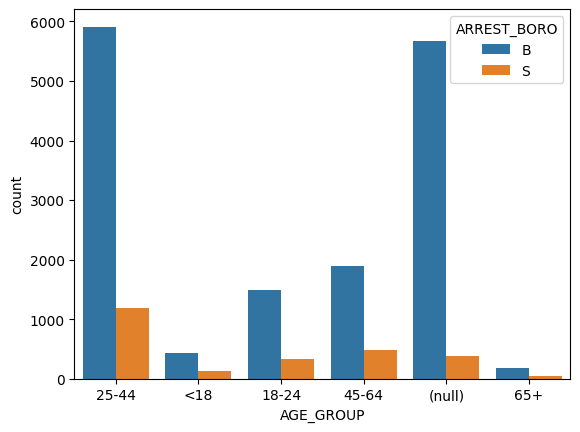

In [ ]:
# 2. Create a bar chart comparing Age Groups for both boroughs.
# 'hue' gives the Bronx and Staten Island different colors so we can compare them.
sns.countplot(data=bx_si_compare, x='AGE_GROUP', hue='ARREST_BORO')

While checking my bar chart, I noticed a category labeled "(null)". Even though I already used .dropna() to remove empty cells, some rows in this specific dataset have the actual word "(null)" typed inside them as text.To make my analysis accurate, I am adding a step to filter out these specific rows. This ensures my final chart only shows real age groups and isn't skewed by incorrect data.

In [ ]:
# 1. This line removes any row where the Age Group is the word '(null)'.
# Doing this because these rows don't have real age information.
bx_si_compare = bx_si_compare[bx_si_compare['AGE_GROUP'] != '(null)']

In [ ]:
# 1. Checking the unique values again to make sure '(null)' is gone.
bx_si_compare['AGE_GROUP'].unique()

array(['25-44', '<18', '18-24', '45-64', '65+'], dtype=object)

In [ ]:
# 1. Create the final bar chart using our cleaned data.
# This chart compares age groups between the Bronx (B) and Staten Island (S).
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='AGE_GROUP', ylabel='count'>

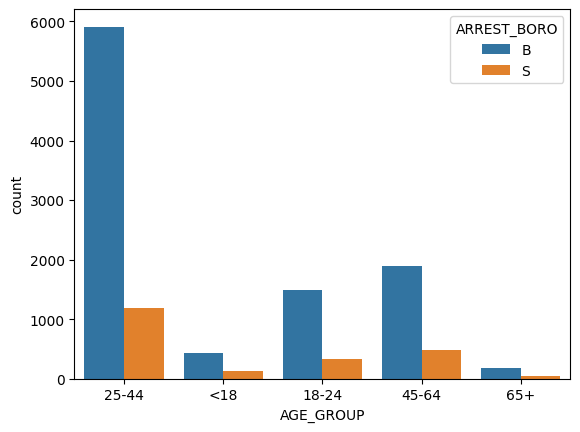

In [ ]:
# 2. Draw the bars. 'hue' gives each borough its own color for easy comparison.
sns.countplot(data=bx_si_compare, x='AGE_GROUP', hue='ARREST_BORO')

Text(0, 0.5, 'Number of Arrests')

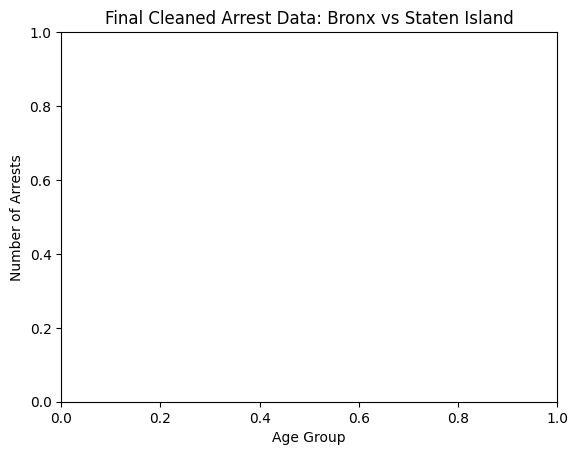

In [ ]:
# 3. Add a clear title and labels so the results are easy to understand.
plt.title('Final Cleaned Arrest Data: Bronx vs Staten Island')
plt.xlabel('Age Group')
plt.ylabel('Number of Arrests')

I noticed my chart was blank and only showing the labels. This happened because the code to draw the bars and the code for the titles weren't running at the same time. I am putting all the code into one cell now to make sure the chart displays correctly.

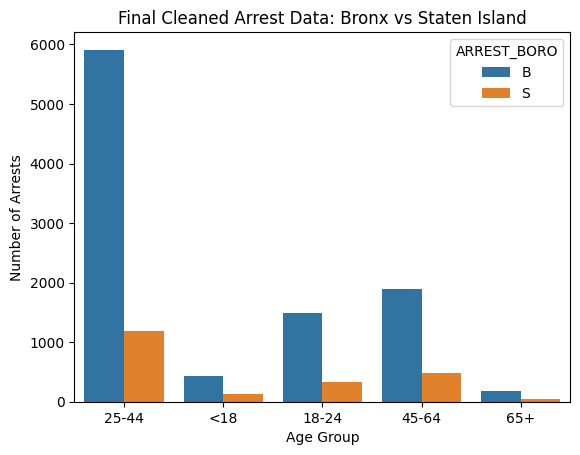

In [ ]:
# 1. We combine all visualization steps into one cell to ensure the chart draws correctly.
import seaborn as sns
import matplotlib.pyplot as plt

# 2. This is the main command that draws the bars for our comparison.
sns.countplot(data=bx_si_compare, x='AGE_GROUP', hue='ARREST_BORO')

# 3. We add the labels and title in the same step so they attach to the correct chart.
plt.title('Final Cleaned Arrest Data: Bronx vs Staten Island')
plt.xlabel('Age Group')
plt.ylabel('Number of Arrests')

# 4. Display the final completed visualization.
plt.show()

Final Project Conclusion

My Findings: I compared the Bronx and Staten Island and found that the Bronx has many more arrests in every age group. In both boroughs, people aged 25 to 44 are arrested the most.

Why the data is biased: Just because the Bronx has more arrests doesn't mean it has more crime. The data is biased for a few simple reasons:

*   Police Presence: If the city sends more police officers to the Bronx than to Staten Island, they will naturally catch and arrest more people there.
*   Population: The Bronx is much more crowded. More people living close together usually leads to more police reports than a quiet area like Staten Island.
*   Human Error: The data depends on what an officer writes down at the moment of arrest. They might make mistakes or have their own biases when recording someone's details.